# Analiza przeżycia czasu do porzucenia studiów w kohorcie studentów

## Streszczenie kierownicze

**Kontekst.** Biuro badań instytucjonalnych czteroletniej uczelni chce zrozumieć *kiedy*, a nie tylko *czy*, studenci odchodzą. Kohorta studentów pierwszorocznych jest śledzona semestr po semestrze od momentu immatrykulacji; część kończy studia, część je porzuca, a nieliczni pozostają wciąż zapisani w chwili zamknięcia okna obserwacji. Ponieważ wynik dla studentów wciąż zapisanych jest nieznany (cenzurowanie prawostronne) oraz ponieważ ukończenie studiów usuwa studenta z puli zagrożonych, nie będąc porzuceniem, zwykła regresja typu zaliczył/nie zaliczył odrzuca informację o czasie i obciąża każde oszacowanie ignorujące cenzurowanie. Właściwym narzędziem jest **analiza czasu do zdarzenia (analiza przeżycia)**, w której interesującym zdarzeniem jest **porzucenie studiów**, a zegar mierzony jest w zaliczonych semestrach akademickich.

**Pytanie biznesowe.** Czy **status akademicki studenta w pierwszym semestrze** (flaga wczesnego ostrzegania) rozdziela trajektorie czasu do porzucenia w kohorcie oraz które cechy studenta napędzają hazard porzucenia po skorygowaniu? Odpowiedzi zasilają system wczesnego ostrzegania: studenci, których szacowany hazard porzucenia jest wysoki, powinni otrzymać wsparcie doradcze w pierwszych semestrach, kiedy interwencja jest najtańsza i najbardziej skuteczna.

**Podejście.** Symulujemy kohortę 100 studentów w kodzie (bez danych zewnętrznych), a następnie przechodzimy przez standardowy przepływ pracy analizy przeżycia:

1. **PROC MEANS** profiluje predyktory w trzech obserwowanych wynikach (Ukończył / Porzucił / wciąż Zapisany), aby potwierdzić, że symulowany sygnał zachowuje się sensownie.
2. **PROC FREQ** krzyżuje status akademicki pierwszego semestru z wynikiem, wraz z testem chi-kwadrat na związek.
3. **PROC UNIVARIATE** raportuje odporne percentyle czasu do porzucenia według statusu.
4. **PROC LIFETEST** estymuje krzywe porzucenia Kaplana-Meiera z warstwowaniem według statusu i przeprowadza testy równości **log-rank** oraz **Wilcoxona**.
5. **PROC PHREG** dopasowuje wielowymiarowy model **proporcjonalnych hazardów Coxa** dla hazardu porzucenia, z efektem `CLASS` kodowanym względem referencji, obsługą powiązań metodą Efrona oraz przedziałami ufności typu risk-limit.

**Co pokazują dane.** Spośród 100 symulowanych studentów **49 porzuciło, 49 ukończyło, a 2 pozostało zapisanych** w punkcie odcięcia 12 semestrów. Studenci oznaczeni flagą **ostrzeżenia akademickiego** w pierwszym semestrze (średnia z pierwszego semestru poniżej 2,5) porzucają studia znacznie szybciej niż studenci w dobrym standingu: mediana czasu do porzucenia **3,8 semestru vs 8,7 semestru**, co potwierdza test log-rank (chi-kwadrat = 10,73, *p* = 0,0011). Model Coxa identyfikuje średnią z pierwszego semestru (iloraz hazardu 0,21 na punkt średniej, *p* < 0,0001), średnią ze szkoły średniej (HR 0,45, *p* = 0,027) oraz status pierwszego pokolenia (HR 2,03, *p* = 0,031) jako istotne skorygowane czynniki napędzające porzucenie, natomiast status stypendium Pell nie jest istotny po uwzględnieniu średniej (HR 0,95, *p* = 0,85).

> *Wszystkie liczby mają charakter poglądowy i zostały wygenerowane z danych syntetycznych; nie są to prawdziwe rejestry studentów. To środowisko działa bez licencji, więc kohorta ma rozmiar 100 studentów.*

## Źródła danych

Wszystkie dane są **syntetyczne**, generowane w kodzie w pierwszym kroku DATA za pomocą `CALL STREAMINIT(20260611)` i funkcji `RAND`. Brak plików zewnętrznych lub dostępu do sieci. Jeden wiersz na jednego symulowanego studenta.

**Zbiór danych `enrollments`** (100 wierszy, jeden wiersz na studenta)

| Zmienna | Typ | Opis | Rozkład generujący |
|----------|------|-------------|--------------------------|
| `student_id` | Num | Unikalny klucz studenta | sekwencja 1–100 |
| `first_gen` / `first_gen_lbl` | Num / Char | Flaga pierwszego pokolenia (0/1) i etykieta | Bernoulli, ~42% |
| `pell` | Num | Flaga stypendium Pell (potrzeba finansowa) (0/1) | Bernoulli, ~42% |
| `program` | Char | STEM / BUS / HUM | kategoryczny (~42% / 32% / 26%) |
| `hs_gpa` | Num | Średnia ze szkoły średniej (1,8–4,0) | Normalny(3,00, 0,42), przycięty |
| `term1_gpa` | Num | Średnia z pierwszego semestru studiów (0–4,0) | f(hs_gpa, program) + szum Normalny |
| `standing` | Char | Status akademicki pierwszego semestru | `term1_gpa < 2.5` → Ostrzeżenie akademickie, w przeciwnym razie Dobry standing |
| `time_terms` | Num | Semestry zapisu do zdarzenia lub cenzurowania | konkurencyjne losowania Weibulla; ograniczone do 12 |
| `dropped` | Num | Wskaźnik zdarzenia porzucenia (1 = porzucił, 0 = cenzurowany) | pochodny |
| `outcome` | Char | Ukończył / Porzucił / Zapisany | pochodny z konkurencyjnych losowań |

Ukryty predyktor liniowy na skali logarytmicznej wiąże **wskaźnik porzucenia** każdego studenta ze średnią z pierwszego semestru, średnią ze szkoły średniej, statusem pierwszego pokolenia i potrzebą finansową, tak że predyktory niosą prawdziwy, lecz zaszumiony sygnał. Porzucenie i ukończenie są losowane jako **konkurencyjne** ukryte czasy (Weibull); to, które nastąpi pierwsze w oknie 12 semestrów, staje się obserwowanym wynikiem, a studenci, którzy osiągną semestr 12 bez żadnego z nich, są cenzurowani prawostronnie. Dla modeli przeżycia **zdarzeniem jest porzucenie** (`dropped = 1`); ukończenie i trwający zapis są traktowane jako cenzurowanie (`dropped = 0`).

## 1. Symulacja kohorty studentów

Pierwsza komórka buduje syntetyczną kohortę 100 studentów. Ukryty predyktor liniowy na skali logarytmicznej wiąże wskaźnik porzucenia każdego studenta ze średnią z pierwszego semestru, średnią ze szkoły średniej, statusem pierwszego pokolenia i statusem Pell. Porzucenie i ukończenie są generowane jako **konkurencyjne** ukryte czasy (losowania Weibulla); to, które nastąpi pierwsze w oknie obserwacji 12 semestrów, staje się obserwowanym wynikiem, a studenci, którzy osiągną semestr 12 bez porzucenia lub ukończenia, są cenzurowani prawostronnie. Średnia z pierwszego semestru poniżej 2,5 oznacza studenta flagą **ostrzeżenia akademickiego** — sygnał wczesnego ostrzegania, który testujemy w kroku przeżycia. Losowania korzystają z `CALL STREAMINIT` dla odtwarzalności oraz z funkcji `RAND` dla rozkładów jednostajnego, normalnego i Weibulla. Twarde progi i przycięcia utrzymują każdą wartość w wiarygodnym zakresie (średnie w 0–4,0).

In [1]:
DANE enrollments;
    CALL streaminit(20260611);
    DŁUGOŚĆ standing $40 first_gen_lbl $40 program $4 outcome $16;

    ETYKIETA student_id    = "Identyfikator studenta"
          first_gen     = "Flaga pierwszego pokolenia"
          first_gen_lbl = "Status pierwszego pokolenia"
          pell          = "Stypendium Pell"
          program       = "Kierunek studiów"
          hs_gpa        = "Średnia ze szkoły średniej"
          term1_gpa     = "Średnia z pierwszego semestru"
          standing      = "Status akademicki (1. semestr)"
          time_terms    = "Semestry do zdarzenia lub cenzurowania"
          dropped       = "Wskaźnik zdarzenia porzucenia"
          outcome       = "Wynik";

    POWTÓRZ student_id = 1 TO 100;
        /* Flagi pierwszego pokolenia i potrzeby finansowej */
        first_gen = (rand("uniform") < 0.42);
        JEŚLI first_gen WTEDY first_gen_lbl = "Pierwsze pokolenie";
        PRZECIWNIE            first_gen_lbl = "Kontynuujący pokolenie";
        pell = (rand("uniform") < 0.42);

        /* Kierunek studiów */
        v = rand("uniform");
        JEŚLI      v < 0.42 WTEDY program = "STEM";
        PRZECIWNIE JEŚLI v < 0.74 WTEDY program = "BUS";
        PRZECIWNIE                  program = "HUM";

        /* Przygotowanie akademickie i wyniki pierwszego semestru */
        hs_gpa = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        term1_gpa = round(MIN(4.0, MAX(0.0,
                     0.55*hs_gpa + 1.05 + 0.12*(program="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Flaga wczesnego ostrzegania: średnia 1. semestru poniżej 2,5 = ostrzeżenie akademickie */
        JEŚLI term1_gpa < 2.5 WTEDY standing = "Ostrzeżenie akademickie";
        PRZECIWNIE                  standing = "Dobry standing";

        /* Ukryty hazard porzucenia na skali logarytmicznej: niższa średnia,
           pierwsze pokolenie i status Pell podnoszą wskaźnik porzucenia. */
        eta = -1.05
             - 1.45*(term1_gpa - 2.8)
             - 0.55*(hs_gpa - 3.0)
             + 1.05*first_gen
             + 0.45*pell;
        drop_rate = EXP(eta);

        /* Konkurencyjne ukryte czasy (semestry): porzucenie vs ukończenie */
        t_drop = rand("weibull", 1.2, 7.0) / MAX(0.30, drop_rate);
        t_grad = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(term1_gpa - 2.8));

        /* Administracyjne okno cenzurowania 12 semestrów */
        censor_at = 12;
        JEŚLI t_drop <= t_grad AND t_drop <= censor_at WTEDY POWTÓRZ;
            outcome = "Porzucił";   dropped = 1; time_terms = t_drop;
        KONIEC;
        PRZECIWNIE JEŚLI t_grad < t_drop AND t_grad <= censor_at WTEDY POWTÓRZ;
            outcome = "Ukończył"; dropped = 0; time_terms = t_grad;
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            outcome = "Zapisany";  dropped = 0; time_terms = censor_at;
        KONIEC;
        time_terms = round(time_terms, 0.1);
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ student_id first_gen first_gen_lbl pell program hs_gpa
         term1_gpa standing time_terms dropped outcome;
WYKONAJ;


NOTE: DATA enrollments


NOTE: Wrote enrollments (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profilowanie predyktorów według obserwowanego wyniku

Przed modelowaniem potwierdzamy, że symulowane predyktory poruszają się w oczekiwanych kierunkach. **PROC MEANS** raportuje liczebność, średnią, rozproszenie i zakres każdego predyktora numerycznego w trzech obserwowanych wynikach.

Kohorta dzieli się na **49 Ukończyło / 49 Porzuciło / 2 wciąż Zapisanych**. Absolwenci mają wyższą średnią z pierwszego semestru (średnia **2,94** vs **2,54** dla studentów, którzy porzucili) oraz wyższą średnią ze szkoły średniej (**3,10** vs **2,90**) — dokładnie gradient przygotowania akademickiego, jakiego analiza oczekuje. Dwaj wciąż zapisani studenci znajdują się dokładnie na pułapie cenzurowania 12 semestrów dla `time_terms` (średnia 12,00, odchylenie standardowe 0), czyli na cenzurowaniu prawostronnym, które analiza odsiewu musi respektować. Wśród studentów, którzy porzucili, zdarzenie przychodzi wcześnie: średnia **3,31 semestru**, w zakresie od 0,1 do 8,9.

In [2]:
TYTUŁ "Profil predyktorów według obserwowanego wyniku";
PROCEDURA ŚREDNIE DANE=enrollments n mean std MIN MAX maxdec=2;
    KLASA outcome;
    ZMIENNA hs_gpa term1_gpa time_terms;
WYKONAJ;
TYTUŁ;

                                     Profil predyktorów według obserwowanego wyniku                                     

                                                  The MEANS Procedure

                                Analysis Variable : hs_gpa Średnia ze szkoły średniej

        Wynik               N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Porzucił               49           2.90           0.45           2.01           3.89
        Ukończył               49           3.10           0.46           1.97           4.00
        Zapisany                2           3.10           0.17           2.98           3.22
        -------------------------------------------------------------------------------------

                              Analysis Variable : term1_gpa Średnia z pierwszego semestru

        Wynik               N Obs           Mean        Std Dev 


NOTE: Option TITLE changed to Profil predyktorów według obserwowanego wyniku.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Czy flaga wczesnego ostrzegania śledzi wynik?

System wczesnego ostrzegania oznacza flagą **ostrzeżenia akademickiego** każdego studenta, którego średnia z pierwszego semestru spada poniżej 2,5. **PROC FREQ** krzyżuje tę flagę z obserwowanym wynikiem i przeprowadza test chi-kwadrat na związek. Tłumimy odsetki wierszowe, kolumnowe i całkowite (`NOROW NOCOL NOPERCENT`), aby tabela pokazywała surowe liczebności, i dodajemy jednowymiarowe częstości `standing` oraz statusu pierwszego pokolenia dla składu kohorty.

Tabela krzyżowa jest wyrazista: spośród **29** studentów oznaczonych flagą ostrzeżenia akademickiego **21 porzuciło**, a jedynie 8 ukończyło; spośród **71** w dobrym standingu **41 ukończyło**, a 28 porzuciło. Związek jest istotny (chi-kwadrat = 9,21, df = 2, *p* = 0,0100; V Craméra = 0,30). Zwróć uwagę na **ostrzeżenie wydrukowane razem z nią**: przy 100 studentach i cienkiej kolumnie "Zapisany" z dwoma absolwentami jedna trzecia komórek tabeli ma oczekiwane liczebności poniżej 5, więc wartość *p* chi-kwadrat jest tutaj krucha. Właśnie ta kruchość jest powodem, dla którego testy przeżycia w kolejnych sekcjach — które wykorzystują pełną informację o czasie, a nie tabelę 3×2 — są bardziej wiarygodnym testem efektu statusu.

                                         Status akademicki 1. semestru a wynik                                          

                                                   The FREQ Procedure

Table of Status akademicki (1. semestr) by Wynik

Status akademicki (1. semestr) |  Porzucił |  Ukończył |  Zapisany |      Total
-------------------------------+-----------+-----------+-----------+-----------
Dobry standing                 |        28 |        41 |         2 |         71
-------------------------------+-----------+-----------+-----------+-----------
Ostrzeżenie akademickie        |        21 |         8 |         0 |         29
-------------------------------+-----------+-----------+-----------+-----------
Total                          |        49 |        49 |         2 |        100

Statistics for Table of Status akademicki (1. semestr) by Wynik

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-


NOTE: Option TITLE changed to Status akademicki 1. semestru a wynik.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_standing_outcome.spec.json
NOTE: ODS plot written: freq_standing.spec.json
NOTE: ODS plot written: freq_first_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


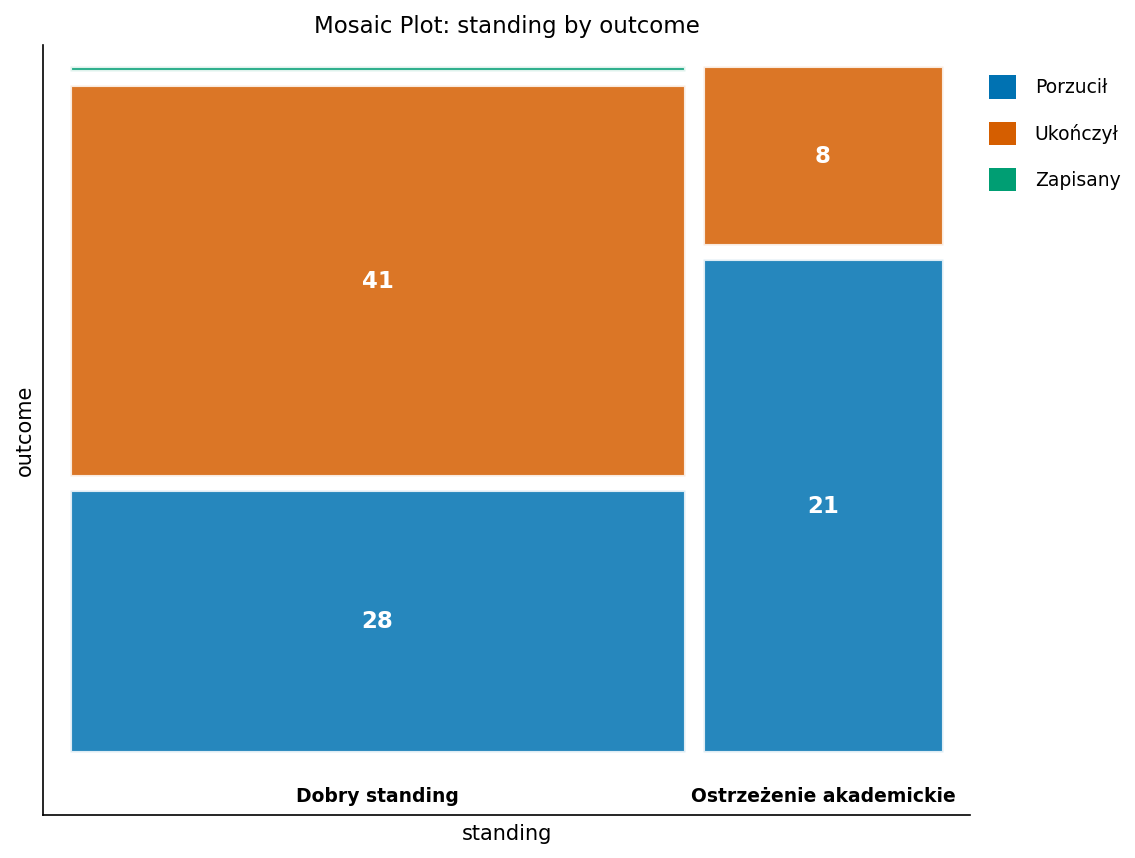

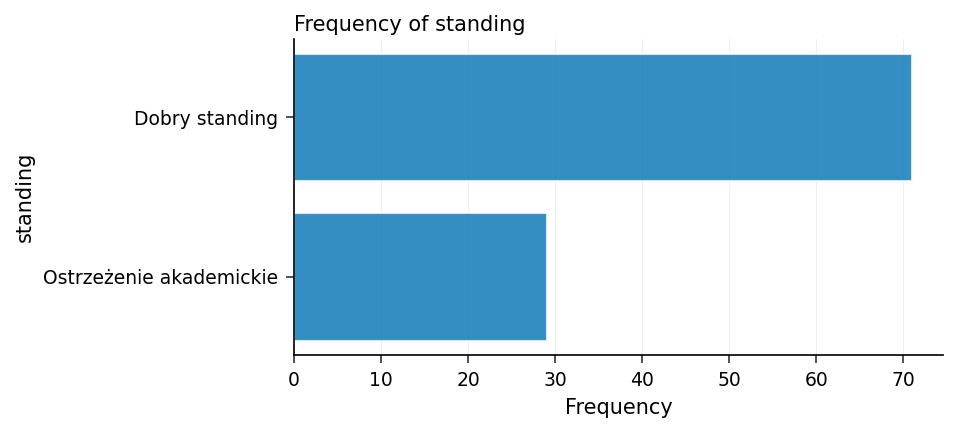

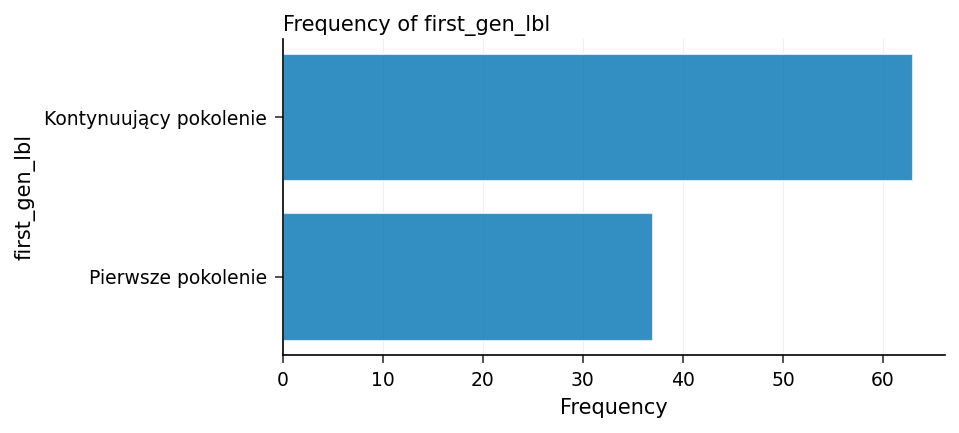

In [3]:
TYTUŁ "Status akademicki 1. semestru a wynik";
PROCEDURA CZĘSTOŚCI DANE=enrollments;
    TABLES standing*outcome / chisq norow nocol nopercent;
    TABLES standing first_gen_lbl;
WYKONAJ;
TYTUŁ;

## 4. Kiedy następują porzucenia? Percentyle według statusu

Dla studentów, którzy rzeczywiście porzucili, *kiedy* odeszli? **PROC UNIVARIATE** (ograniczony do `dropped = 1`) raportuje 10., 50. (mediana) i 90. percentyl czasu do porzucenia w każdej grupie statusu, zapisany do wyjściowego zbioru danych, który następnie drukujemy. Opisuje to rozproszenie czasu porzucenia bez zakładania rozkładu.

Mediana porzucenia wśród studentów, którzy odeszli, następuje około semestru **2,4** (ostrzeżenie akademickie) w porównaniu z **2,6** (dobry standing) — blisko siebie, ponieważ *pod warunkiem porzucenia* obie grupy zwykle odchodzą wcześnie. Efekt statusu nie dotyczy więc głównie tego, *kiedy* następuje porzucenie, lecz tego, *ilu* studentów porzuca i jak szybko przerzedza się pula zagrożonych, co dokładnie ujmują krzywe Kaplana-Meiera w kolejnej sekcji.

In [4]:
PROCEDURA UNIVARIATE DANE=enrollments NOPRINT;
    GDZIE dropped = 1;
    KLASA standing;
    ZMIENNA time_terms;
    WYJŚCIE out=drop_ref pctlpts=10 50 90 pctlpre=t_ p=;
WYKONAJ;

PROCEDURA DRUKUJ DANE=drop_ref noobs ETYKIETA;
    TYTUŁ "Percentyle czasu do porzucenia (semestry) według statusu akademickiego";
WYKONAJ;
TYTUŁ;

                         Percentyle czasu do porzucenia (semestry) według statusu akademickiego                         

                STANDING  T_10  T_50  T_90
Dobry standing             0.4   2.6   8.7
Ostrzeżenie akademickie    0.2   2.4   7.9




NOTE: PROC UNIVARIATE
NOTE: Output dataset drop_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=drop_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Krzywe porzucenia Kaplana-Meiera według statusu akademickiego

Teraz główny krok analizy przeżycia. **PROC LIFETEST** estymuje nieparametryczną funkcję przeżycia **Kaplana-Meiera** dla *czasu do porzucenia*, traktując ukończenie i trwający zapis jako cenzurowanie (`dropped(0)` oznacza obserwacje cenzurowane). Warstwowanie według `standing` daje jedną krzywą porzucenia na grupę, a `TEST=(LOGRANK WILCOXON)` przeprowadza dwa uzupełniające się testy tego, czy te krzywe się różnią: test **log-rank** waży wszystkie czasy zdarzeń jednakowo (wrażliwy na różnice późne), natomiast test **Wilcoxona** nadaje większą wagę wczesnym czasom zdarzeń (wrażliwy na wczesny odsiew). `PLOTS=SURVIVAL` żąda nałożonej grafiki krzywych przeżycia.

W całej kohorcie występuje **49 zdarzeń porzucenia i 51 obserwacji cenzurowanych**. Krzywe rozdzielają się wyraźnie: studenci na ostrzeżeniu akademickim osiągają **medianę przeżycia (czasu do porzucenia) 3,8 semestru**, natomiast studenci w dobrym standingu wytrzymują ponad dwukrotnie dłużej (**8,7 semestru**). Oba testy odrzucają równość — **chi-kwadrat log-rank = 10,73, *p* = 0,0011; chi-kwadrat Wilcoxona = 7,66, *p* = 0,0056** — a porównywalne statystyki mówią nam, że różnica utrzymuje się w całym oknie zapisu, a nie tylko jako wczesny skok. Wykres czyni przekaz natychmiastowym: pomarańczowa krzywa ostrzeżenia akademickiego spada stromo przez pierwsze cztery semestry, podczas gdy niebieska krzywa dobrego standingu pozostaje wysoko.

                             Krzywe porzucenia Kaplana-Meiera według statusu akademickiego                              

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Status akademicki (1. semestr) = Dobry standing

                             N
--------------------  --------
Total                       71
Event                       28
Censored                    43
Median Survival Time    8.7000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9859     0.0140              71                 1
  0.2000    0.9718     0.0196              70                 1
  0.4000    0.9577     0.0239              69                 1
  0.5000    0.9437     0.0274


NOTE: Option TITLE changed to Krzywe porzucenia Kaplana-Meiera według statusu akademickiego.
NOTE: PROC LIFETEST data=enrollments

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


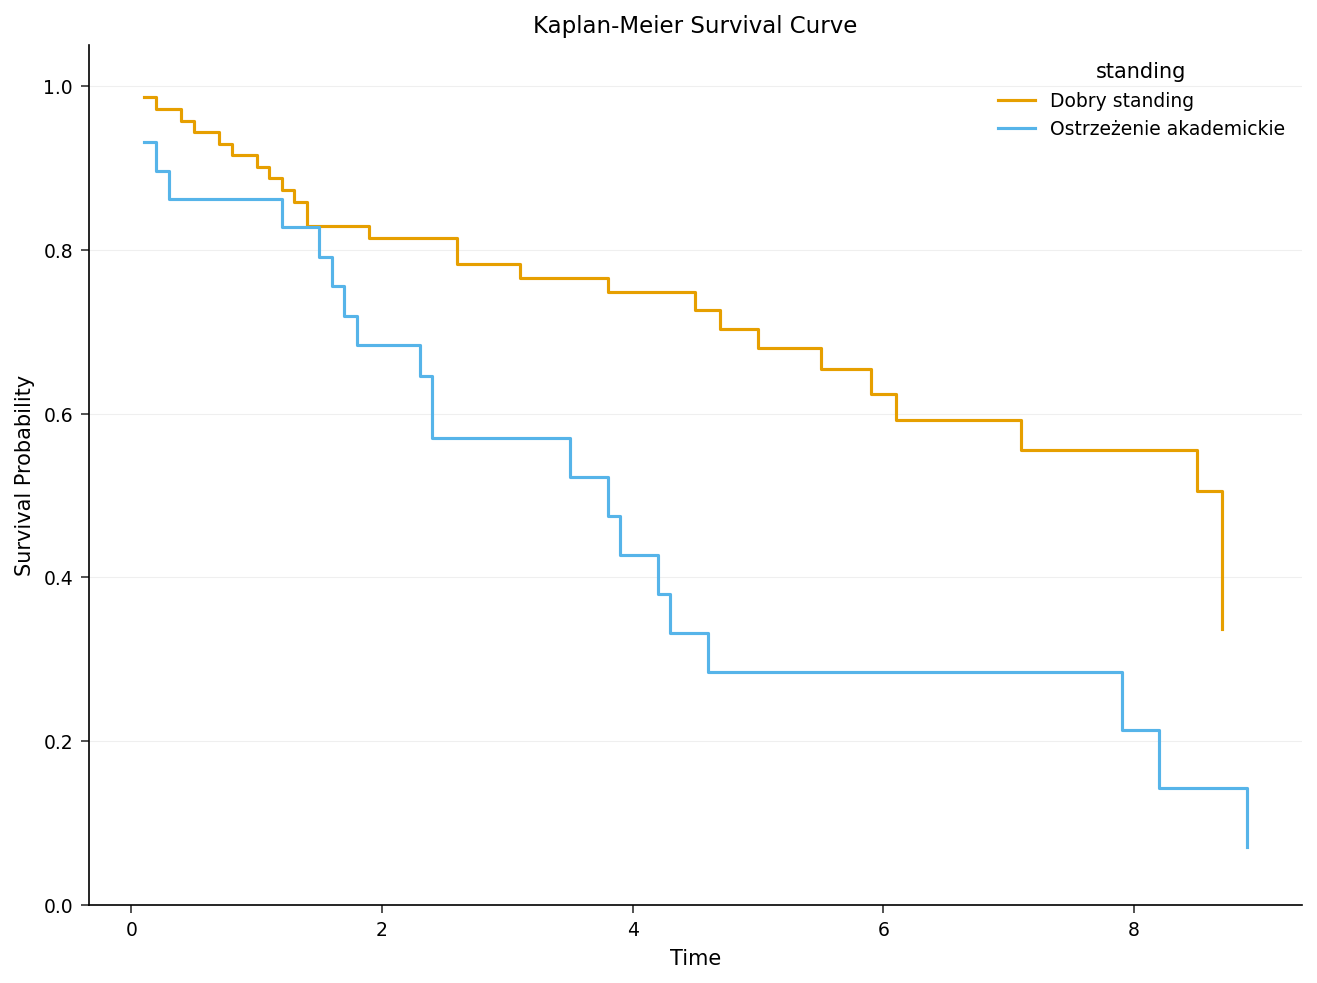

In [5]:
TYTUŁ "Krzywe porzucenia Kaplana-Meiera według statusu akademickiego";
PROCEDURA LIFETEST DANE=enrollments PLOTS=SURVIVAL METHOD=km;
    TIME time_terms*dropped(0);
    STRATA standing / TEST=(logrank WILCOXON);
WYKONAJ;
TYTUŁ;

## 6. Wielowymiarowy model proporcjonalnych hazardów Coxa dla porzucenia

**PROC PHREG** dopasowuje model **proporcjonalnych hazardów Coxa** dla hazardu porzucenia, korygując predyktory jednocześnie. Kluczowe żądania:

- `dropped(0)` czyni **porzucenie** zdarzeniem, a wszystko inne cenzurowaniem.
- `CLASS first_gen_lbl (ref="Continuing-gen") / param=ref` koduje względem referencji czynnik pierwszego pokolenia, tak że jego iloraz hazardu odczytuje się względem studentów kontynuujących pokolenie.
- `TIES=EFRON` to rekomendowane przybliżenie obsługi powiązań, gdy kilku studentów odchodzi w tym samym semestrze.
- `RL` dodaje przedziały ufności ilorazu hazardu (risk-limit).
- Instrukcja `HAZARDRATIO` raportuje kontrast pierwszego pokolenia względem grupy referencyjnej.

Iloraz hazardu powyżej 1 oznacza *szybsze* porzucenie (wyższe ryzyko); poniżej 1 oznacza *wolniejsze* porzucenie (ochronne).

In [6]:
TYTUŁ "Model proporcjonalnych hazardów Coxa dla porzucenia";
PROCEDURA PHREG DANE=enrollments;
    KLASA first_gen_lbl (REF="Kontynuujący pokolenie") / PARAM=REF;
    MODEL time_terms*dropped(0) = hs_gpa term1_gpa first_gen_lbl pell
          / TIES=efron rl;
    hazardratio "Pierwsze pokolenie vs kontynuujący" first_gen_lbl / DIFF=REF;
WYKONAJ;
TYTUŁ;

                                  Model proporcjonalnych hazardów Coxa dla porzucenia                                   

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                               Analysis of Maximum Likelihood Estimates                                               

Parameter                               DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
---------


NOTE: Option TITLE changed to Model proporcjonalnych hazardów Coxa dla porzucenia.
NOTE: PROC PHREG data=enrollments

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretacja i kolejne kroki

**Odczytanie wyników, od początku do końca:**

- **PROC MEANS** potwierdza symulowany sygnał: studenci, którzy ukończyli, mają wyższą średnią z pierwszego semestru (2,94 vs 2,54) i średnią ze szkoły średniej (3,10 vs 2,90) niż studenci, którzy porzucili, a studenci wciąż zapisani znajdują się na pułapie 12 semestrów — czyli na cenzurowaniu prawostronnym, które modele przeżycia respektują.
- **PROC FREQ** pokazuje, że flaga ostrzeżenia akademickiego pierwszego semestru śledzi wynik (21 z 29 oznaczonych studentów porzuciło; 41 z 71 studentów w dobrym standingu ukończyło; *p* = 0,0100), uczciwie sygnalizując zarazem, że chi-kwadrat jest kruchy w tabeli 100 studentów z rzadkimi komórkami.
- **PROC UNIVARIATE** pokazuje, że *pod warunkiem porzucenia* obie grupy odchodzą wcześnie (mediana ~2,4–2,6 semestru); efekt statusu dotyczy tego, ilu studentów porzuca i jak szybko przerzedza się pula zagrożonych, a nie czasu wśród tych, którzy odchodzą.
- **PROC LIFETEST** dostarcza nagłówek: krzywe porzucenia Kaplana-Meiera, które rozdzielają się ostro według statusu (mediana 3,8 vs 8,7 semestru; log-rank *p* = 0,0011, Wilcoxon *p* = 0,0056). Flaga wczesnego ostrzegania jest prawdziwym, statystycznie potwierdzonym dyskryminatorem czasu do porzucenia.
- **PROC PHREG** kwantyfikuje skorygowany efekt każdego predyktora na hazard porzucenia. Po skorygowaniu **średnia z pierwszego semestru jest najsilniejszym czynnikiem ochronnym** (iloraz hazardu 0,21 na punkt średniej, 95% CI 0,10–0,44, *p* < 0,0001): każdy dodatkowy punkt średniej obniża hazard porzucenia o mniej więcej cztery piąte. **Średnia ze szkoły średniej** jest również ochronna (HR 0,45, 95% CI 0,22–0,91, *p* = 0,027). **Studenci pierwszego pokolenia** stają wobec około dwukrotnie wyższego hazardu porzucenia niż ich rówieśnicy kontynuujący pokolenie o tych samych średnich (HR 2,03, 95% CI 1,07–3,84, *p* = 0,031). **Status Pell nie jest istotny** po uwzględnieniu średniej (HR 0,95, 95% CI 0,53–1,69, *p* = 0,85) — użyteczne przypomnienie, że surowy czynnik ryzyka może zniknąć po skorygowaniu. Globalna hipoteza zerowa jest zdecydowanie odrzucona (chi-kwadrat ilorazu wiarygodności = 31,11 przy 4 df, *p* < 0,0001).

**Jak instytucja działałaby na tej podstawie.** Model Coxa produkuje predyktor liniowy na studenta (wynik ryzyka), który porządkuje kohortę według hazardu porzucenia; studenci najwyższego ryzyka — niska średnia z pierwszego semestru w połączeniu ze statusem pierwszego pokolenia — są kierowani do wczesnego doradztwa w pierwszych semestrach, kiedy interwencja jest najtańsza i najbardziej skuteczna. Porównanie Kaplana-Meiera daje doradcom jedno, obronialne kryterium, które i tak już zbierają na koniec pierwszego semestru: status akademicki.

**Zastrzeżenia i rozszerzenia.** (1) Ta syntetyczna kohorta traktuje ukończenie jako cenzurowanie w modelu porzucenia; przy prawdziwych danych ukończenie i porzucenie są rzeczywistymi **ryzykami konkurencyjnymi**, a rozszerzenie o ryzyka konkurencyjne (skumulowana incydencja) poprzez PROC PHREG `EVENTCODE=` uniknęłoby zawyżania prawdopodobieństwa porzucenia. (2) Założenie proporcjonalnych hazardów powinno zostać sprawdzone (PHREG `ASSESS PH` lub reszty Schoenfelda) przed zaufaniem pojedynczemu ilorazowi hazardu w całym zakresie semestrów. (3) Współzmienne zmienne w czasie — średnia semestr po semestrze, zmiany pomocy finansowej, obciążenie zajęciami — są częste w danych o retencji i naturalnie obsługiwane przez instrukcje programistyczne PHREG. (4) Kohorta 100 studentów została tu dopasowana do limitu bezlicencyjnego uruchomienia; analiza produkcyjna obejmowałaby kilka tysięcy studentów, zawężając każdy przedział ufności. Zawsze waliduj wdrożony wynik ryzyka na kohorcie wydzielonej, zanim zaczniesz działać na jego podstawie operacyjnie.